In [50]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import copy
import spectroscopic_efficiency

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


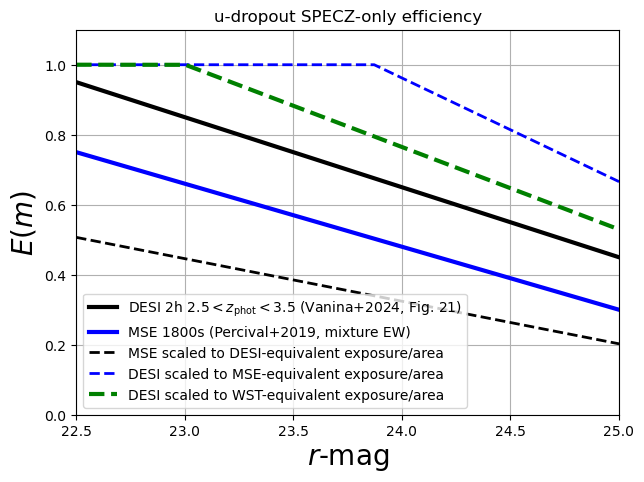

In [51]:
# Magnitude range
m_vals = np.linspace(22., 26, 3400)

def E_mse_udrop_single_exp(m): 
    return np.minimum(np.maximum((-0.18*m + 4.8), 0), 1)
def E_desi_udrop_single_exp(m): 
    return np.minimum(np.maximum(-0.2*(m-23.5) + 0.75, 0), 1)
    #return np.maximum(0.8 - 0.01*(m-24),0)


tMSE = 1800 #MSE time
SMSE = 11.25**2
tDESI= 2 * 60 * 60 #Dark time WST
SDESI = 3.8**2 #Surface of MSE mirror
alpha_MSE_to_DESI = np.sqrt(tDESI * SDESI)/np.sqrt(tMSE * SMSE)



alpha_DESI_to_WST = np.sqrt(1000 * 12**2)/np.sqrt(tDESI * SDESI)
plt.figure(figsize=(7,5))
plt.title('u-dropout SPECZ-only efficiency')
plt.plot(m_vals, E_desi_udrop_single_exp(m_vals), 'k',  lw=3, label = r'DESI 2h $2.5 < z_{\rm phot} < 3.5$ (Vanina+2024, Fig. 21)')
plt.plot(m_vals, E_mse_udrop_single_exp(m_vals), 'b',  lw=3, label = 'MSE 1800s (Percival+2019, mixture EW)')

plt.plot(m_vals, E_mse_udrop_single_exp(m_vals) * alpha_MSE_to_DESI, '--k', lw=2, label = r'MSE scaled to DESI-equivalent exposure/area')


plt.plot(m_vals, np.minimum(E_desi_udrop_single_exp(m_vals)/ alpha_MSE_to_DESI, 1), '--b', lw=2,  label = r'DESI scaled to MSE-equivalent exposure/area')

plt.plot(m_vals, np.minimum(E_desi_udrop_single_exp(m_vals) * alpha_DESI_to_WST, 1), '--g', lw=3,  label = r'DESI scaled to WST-equivalent exposure/area')

#multiplied by $\sqrt{t_{\rm DESI}/t_{\rm MSE}}\times\sqrt{S_{\rm DESI}/S_{\rm MSE}}
plt.legend(ncols=1)
plt.xlabel(r'$r$-mag', fontsize=20)
plt.ylabel(r'$E(m)$', fontsize=20)
plt.xlim(22.5, 25)
plt.ylim(0, 1.1)
plt.grid()

alpha_MSE_to_DESI = 0.676
delta_m_MSE_to_DESI = -0.426 mag
alpha_DESI_to_WST = 1.177
delta_m_DESI_to_WST = 0.177 mag


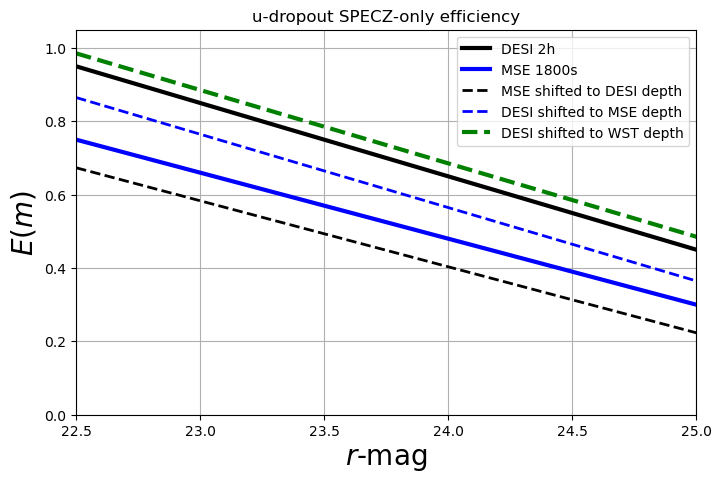

In [52]:
# --- S/N-based rescaling: horizontal magnitude shift ---

import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
m_vals = np.linspace(22., 26, 3400)

# Efficiency curves
def E_mse_udrop_single_exp(m): 
    return np.minimum(np.maximum((-0.18*m + 4.8), 0), 1)

def E_desi_udrop_single_exp(m): 
    return np.minimum(np.maximum(-0.2*(m-23.5) + 0.75, 0), 1)

# Exposure times and collecting areas
tMSE = 1800
SMSE = 11.25**2

tDESI = 2 * 60 * 60
SDESI = 3.8**2

# S/N scaling factor
alpha_MSE_to_DESI = np.sqrt(tDESI * SDESI) / np.sqrt(tMSE * SMSE)

# Magnitude shift corresponding to S/N scaling
delta_m_MSE_to_DESI = 2.5 * np.log10(alpha_MSE_to_DESI)

# DESI -> WST
alpha_DESI_to_WST = np.sqrt(1000 * 12**2) / np.sqrt(tDESI * SDESI)
delta_m_DESI_to_WST = 2.5 * np.log10(alpha_DESI_to_WST)

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
plt.figure(figsize=(8,5))

plt.title('u-dropout SPECZ-only efficiency')

# Original curves
plt.plot(
    m_vals,
    E_desi_udrop_single_exp(m_vals),
    'k',
    lw=3,
    label=r'DESI 2h'
)

plt.plot(
    m_vals,
    E_mse_udrop_single_exp(m_vals),
    'b',
    lw=3,
    label='MSE 1800s'
)

# --- Proper horizontal rescaling ---
# MSE scaled to DESI-equivalent depth
plt.plot(
    m_vals,
    E_mse_udrop_single_exp(m_vals - delta_m_MSE_to_DESI),
    '--k',
    lw=2,
    label=r'MSE shifted to DESI depth'
)

# DESI scaled to MSE-equivalent depth
plt.plot(
    m_vals,
    E_desi_udrop_single_exp(m_vals - delta_m_MSE_to_DESI),
    '--b',
    lw=2,
    label=r'DESI shifted to MSE depth'
)

# DESI scaled to WST-equivalent depth
plt.plot(
    m_vals,
    E_desi_udrop_single_exp(m_vals - delta_m_DESI_to_WST),
    '--g',
    lw=3,
    label=r'DESI shifted to WST depth'
)

# Cosmetics
plt.xlabel(r'$r$-mag', fontsize=20)
plt.ylabel(r'$E(m)$', fontsize=20)

plt.xlim(22.5, 25)
plt.ylim(0, 1.05)

plt.grid()
plt.legend()

print(f'alpha_MSE_to_DESI = {alpha_MSE_to_DESI:.3f}')
print(f'delta_m_MSE_to_DESI = {delta_m_MSE_to_DESI:.3f} mag')

print(f'alpha_DESI_to_WST = {alpha_DESI_to_WST:.3f}')
print(f'delta_m_DESI_to_WST = {delta_m_DESI_to_WST:.3f} mag')

plt.show()

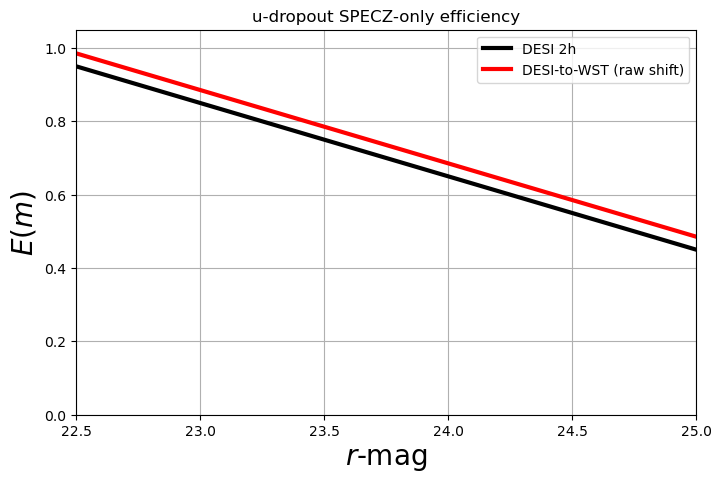

In [53]:
# --- S/N-based rescaling: horizontal magnitude shift ---

import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
m_vals = np.linspace(22., 26, 3400)

# Efficiency curves
def E_mse_udrop_single_exp(m): 
    return np.minimum(np.maximum((-0.18*m + 4.8), 0), 1)

def E_desi_udrop_single_exp(m): 
    return np.minimum(np.maximum(-0.2*(m-23.5) + 0.75, 0), 1)

# Exposure times and collecting areas
tMSE = 1000
SMSE = 12**2

tDESI = 2 * 60 * 60
SDESI = 3.8**2

# S/N scaling factor
alpha_DESI_to_MSE = np.sqrt(tMSE * SMSE) / np.sqrt(tDESI * SDESI)

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
plt.figure(figsize=(8,5))

plt.title('u-dropout SPECZ-only efficiency')

# Original curves
plt.plot(
    m_vals,
    E_desi_udrop_single_exp(m_vals),
    'k',
    lw=3,
    label=r'DESI 2h'
)

plt.plot(
    m_vals,
    E_desi_udrop_single_exp(m_vals - 2.5*np.log10(alpha_DESI_to_MSE )),
    'r',
    lw=3,
    label=r'DESI-to-WST (raw shift)'
)




# Cosmetics
plt.xlabel(r'$r$-mag', fontsize=20)
plt.ylabel(r'$E(m)$', fontsize=20)

plt.xlim(22.5, 25)
plt.ylim(0, 1.05)

plt.grid()
plt.legend()


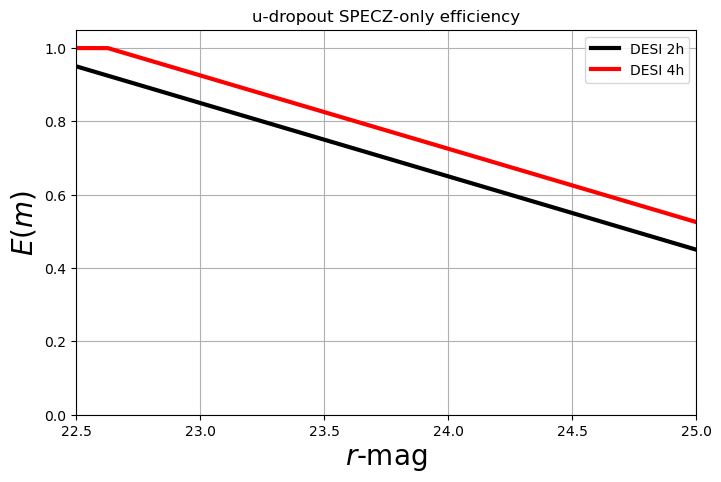

In [54]:
# --- S/N-based rescaling: horizontal magnitude shift ---

import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
m_vals = np.linspace(22., 26, 3400)


def E_desi_udrop_single_exp(m): 
    return np.minimum(np.maximum(-0.2*(m-23.5) + 0.75, 0), 1)


tDESI = 2 * 60 * 60
SDESI = 3.8**2
SMSE = 11.25**2

# S/N scaling factor
alpha_DESI_to_twice_exposure = np.sqrt(2 * tDESI * SDESI) / np.sqrt(tDESI * SDESI)

# ----------------------------------------------------
# Plot
# ----------------------------------------------------
plt.figure(figsize=(8,5))

plt.title('u-dropout SPECZ-only efficiency')

# Original curves
plt.plot(
    m_vals,
    E_desi_udrop_single_exp(m_vals),
    'k',
    lw=3,
    label=r'DESI 2h'
)

plt.plot(
    m_vals,
    E_desi_udrop_single_exp(m_vals - 2.5*np.log10(alpha_DESI_to_twice_exposure)),
    'r',
    lw=3,
    label=r'DESI 4h'
)


# Cosmetics
plt.xlabel(r'$r$-mag', fontsize=20)
plt.ylabel(r'$E(m)$', fontsize=20)

plt.xlim(22.5, 25)
plt.ylim(0, 1.05)

plt.grid()
plt.legend()


/tmp/ipykernel_1219544/462994592.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


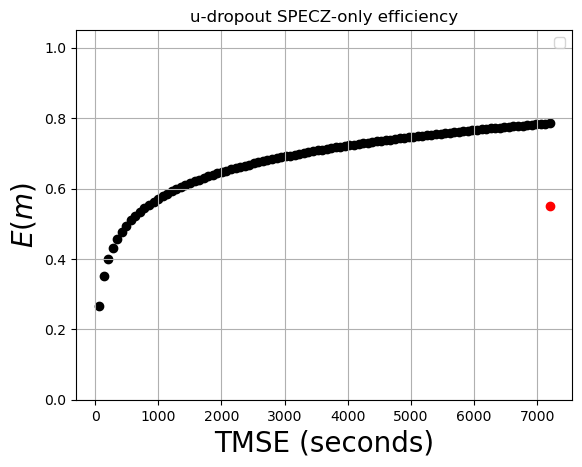

In [55]:
# --- S/N-based rescaling: horizontal magnitude shift ---

import numpy as np
import matplotlib.pyplot as plt

# Magnitude range
m_vals = np.linspace(22., 26, 3400)


def E_desi_udrop_single_exp(m): 
    return np.minimum(np.maximum(-0.2*(m-23.5) + 0.75, 0), 1)


tDESI = 2 * 60 * 60
SDESI = 3.8**2
SMSE = 11.25**2

# S/N scaling factor
alpha_DESI_to_twice_exposure = np.sqrt(2 * tDESI * SDESI) / np.sqrt(tDESI * SDESI)

for tMSE in np.linspace(60, tDESI, 100):
    
    # ----------------------------------------------------
    # Plot
    # ----------------------------------------------------
    
    plt.title('u-dropout SPECZ-only efficiency')
    
    
    plt.scatter(
        tMSE,
        E_desi_udrop_single_exp(24.5 - 2.5*np.log10(np.sqrt(tMSE * SMSE) /np.sqrt(tDESI * SDESI))),color='k',
    )
plt.scatter(
        tDESI,
        E_desi_udrop_single_exp(24.5),color='r',
    )
    
    
    # Cosmetics
plt.xlabel(r'TMSE (seconds)', fontsize=20)
plt.ylabel(r'$E(m)$', fontsize=20)

plt.ylim(0, 1.05)

plt.grid()
plt.legend()


In [29]:
def SNR(m):
    return 10**(-0.4*m) 

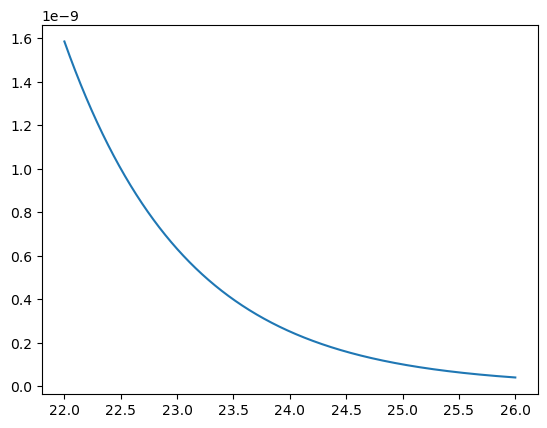

In [30]:
plt.plot(m_vals, SNR(m_vals))